METADATA: {'Title': '2d,1-Hourly,Instantaneous,Single-Level,Analysis,Hyperwall', 'History': 'File written by MAPL_CFIO', 'Source': 'GEOSadas-5_29_5_OPS', 'Contact': 'http://gmao.gsfc.nasa.gov', 'Conventions': 'CF', 'Institution': 'NASA Global Modeling and Assimilation Office', 'References': 'see MAPL documentation', 'Filename': 'f5295_fp.inst1_2d_hwl_Nx.20240201_0000z.nc4', 'Comment': 'NetCDF-4'}
N_VARS: 54

VAR -> LEVEL DIM (if any)
N: 93312
mean: 0.00042719030170701444
std: 1.4958631311401405e-07
min: 0.00042673354619182646
max: 0.00042757642222568393
left_violations: 0
right_violations: 84336


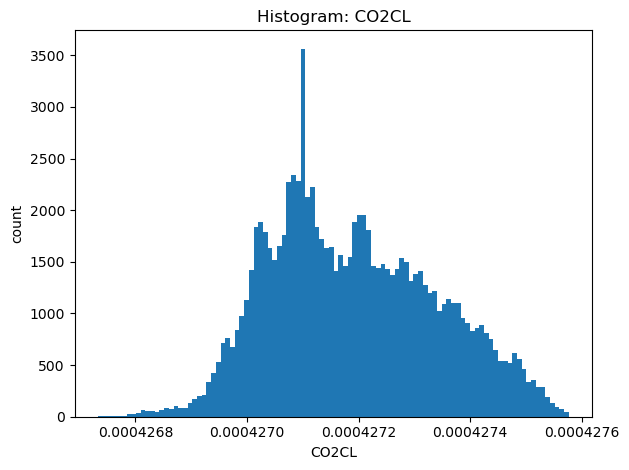

In [20]:
# identify a data chunk with a lot of violations from TUI, and 
# inspect its raw data

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

file =  "/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D01/f5295_fp.inst1_2d_hwl_Nx.20240201_0000z.nc4"

#file = "/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D01/f5294_fp.inst1_2d_hwl_Nx.20230201_0000z.nc4"
ds = xr.open_dataset(file, engine="netcdf4", decode_times=False)

print("METADATA:", dict(ds.attrs))
print("N_VARS:", len(ds.data_vars))

# print variable names and (if present) their vertical/level dimension name + size
print("\nVAR -> LEVEL DIM (if any)")
for name, da in ds.data_vars.items():
    lev_dim = next((d for d in da.dims if d in ("lev", "plev", "level", "eta", "isobaric", "isobaricInhPa")), None)
    #if lev_dim is None:
    #    print(f"{name}: None")
    #else:
    #    print(f"{name}: {lev_dim} (size={da.sizes[lev_dim]})")

# existing chunk/stat code
var = "CO2CL"
lat_name = "lat"
lev_name = "lev"
lat_min, lat_max = -90, -70
level = "NONE"

da = ds[var]

lat_chunk = slice(lat_min, lat_max)
chunk = da.sel({lat_name: lat_chunk})#.isel({lev_name: level})

x = np.asarray(chunk).ravel()
x = x[np.isfinite(x)]

print("N:", x.size)

if x.size == 0:
    print("No finite values")
else:
    print("mean:", float(x.mean()))
    print("std:", float(x.std()))
    print("min:", float(x.min()))
    print("max:", float(x.max()))

    fence_low, fence_high = 0.00042474844444227353, 0.00042700947512700475

    left_violations = int((x < fence_low).sum())
    right_violations = int((x > fence_high).sum())

    print("left_violations:", left_violations)
    print("right_violations:", right_violations)


plt.figure()
plt.hist(x, bins=100)
plt.title(f"Histogram: {var}")
plt.xlabel(var)
plt.ylabel("count")
plt.tight_layout()
plt.show()

In [2]:
## Next collect the historical reference monthly data and inspect that

In [3]:
from calendar import monthrange
from datetime import datetime

import dask.array as da
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from get_collections_and_files import list_files_and_excluded_vars


def monthly_histogram_for_collection(
    model,
    year,
    month,
    collection,
    var,
    data_yaml_file,
    lat_name="lat",
    lev_name="lev",
    lat_min=-90,
    lat_max=-70,
    level=None,
    bins=100,
):
    all_files = []
    excluded = []

    for day in range(1, monthrange(year, month)[1] + 1):
        _, collection_map, excluded_vars = list_files_and_excluded_vars(
            model=model,
            date=datetime(year, month, day),
            data_yaml_file=data_yaml_file,
        )

        all_files.extend(collection_map.get(collection, []))

        if not excluded:
            excluded = excluded_vars

    print(f"Found {len(all_files)} files for collection {collection}")

    ds = xr.open_mfdataset(
        all_files[:1],
        combine="by_coords",
        drop_variables=excluded,
        data_vars="minimal",
        coords="minimal",
        compat="no_conflicts",
        engine="h5netcdf",
        chunks="auto",
        parallel=True,
    )

    da_var = ds[var]

    lat_vals = da_var[lat_name].values
    if lat_vals[0] <= lat_vals[-1]:
        da_var = da_var.sel({lat_name: slice(lat_min, lat_max)})
    else:
        da_var = da_var.sel({lat_name: slice(lat_max, lat_min)})

    if level is not None and lev_name in da_var.dims:
        da_var = da_var.sel({lev_name: level})

    arr = da_var.data
    arr = da.where(da.isfinite(arr), arr, np.nan)

    n = da.sum(~da.isnan(arr)).compute()
    mean_val = da.nanmean(arr).compute()
    std_val = da.nanstd(arr).compute()
    min_val = da.nanmin(arr).compute()
    max_val = da.nanmax(arr).compute()

    print("N:", int(n))
    print("mean:", float(mean_val))
    print("std:", float(std_val))
    print("min:", float(min_val))
    print("max:", float(max_val))

    #finite_vals = arr.ravel()[~da.isnan(arr.ravel())]
    
    flat = arr.ravel()
    finite_vals = flat[da.isfinite(flat)]

    #left_violations = (finite_vals < fence_low).sum().compute()
    #right_violations = (finite_vals > fence_high).sum().compute()
    #print("left_viloations:", left_violations)
    #print("right_violations:", right_violations)
    
    hist, bin_edges = da.histogram(
        finite_vals,
        bins=bins,
        range=(float(min_val), float(max_val)),
    )
    hist = hist.compute()

    plt.figure()
    plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), align="edge")
    plt.title(f"Histogram: {var}")
    plt.xlabel(var)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

    ds.close()

GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D01
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D02
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D03
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D04
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D05
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D06
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D07
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D08
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D09
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D10


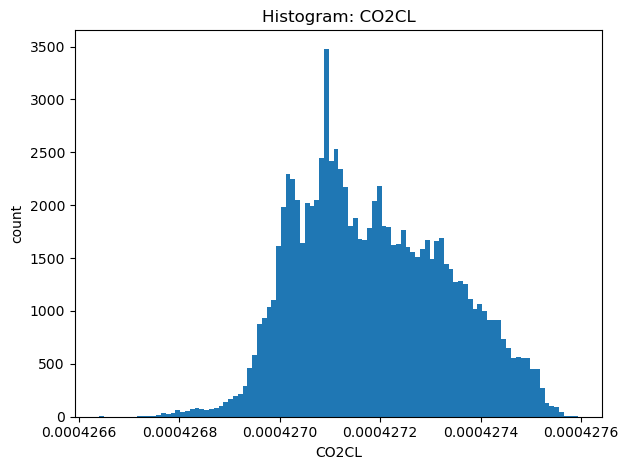

In [4]:
monthly_histogram_for_collection(
    model="GEOSFP",
    year=2024,
    month=2,
    collection="inst1_2d_hwl_Nx",
    var="CO2CL",
    data_yaml_file="/home/sadhika8/JupyterLinks/nobackup/quads/conf/dataserver.yaml",
    lat_name="lat",
    lat_min=-90,
    lat_max=-70,
    level=None,
)

In [5]:
#Found 672 files for collection inst1_2d_hwl_Nx - 2024
#N: 62705664
#mean: 0.00042578778811730444
#std: 1.2309571673085884e-07
#min: 0.0004250694764778018
#max: 0.0004264672170393169

In [6]:
# now inspect the corresponding t-digest computed and saved

In [7]:
#import pandas as pd
#import dask

#path = "/home/sadhika8/JupyterLinks/nobackup/quads_data/GEOSFP/2023/01/test_2023-01-01.pkl"
#lst = pd.read_pickle(path)

#print(type(lst))
#print("len:", len(lst))

#print(len(lst))
#print(lst[0].keys())

In [8]:
#print(sorted(lst[108]["quantiles"]))

In [9]:
#for ind, elem in enumerate(lst):
#    if elem["id_key"] == "inst3_2d_asm_Nx|U50M|None|Strat5":
#        #print (elem["quantiles"])
#        y, x = elem["quantiles"]
#        print(y)

In [10]:
#plt.scatter(x, y)

In [11]:
# now compare it to the database computed by the main code

In [12]:
import sqlite3, pickle, pathlib

db = "/home/sadhika8/JupyterLinks/nobackup/quads_database/geosfp_monthly_aggregated_centroids_and_quantiles.db"
with sqlite3.connect(db) as conn:
    cur = conn.cursor()
    #cur.execute("SELECT COUNT(*) FROM geosfp;")
    #print("rows:", cur.fetchone()[0])

    cur.execute("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%';")
    tables = [row[0] for row in cur.fetchall()]

    print("tables:", tables)

    for t in tables:
        cur.execute(f"PRAGMA table_info({t});")
        cols = [row[1] for row in cur.fetchall()]  # row[1] is column name
        print(f"{t} columns: {cols}")

tables: ['geosfp']
geosfp columns: ['model', 'year', 'month', 'id_string', 'compression', 'centroids', 'quantiles', 'quantile_list']


In [13]:
# inputs you choose
model = "geosfp"          # table name, e.g. "geosfp"
year = 2023
month = 2                 # 1-12
id_string = "inst1_2d_hwl_Nx|CO2CL|None|Strat1"

with sqlite3.connect(db) as conn:
    conn.row_factory = sqlite3.Row
    cur = conn.cursor()

    cur.execute(
        f"""
        SELECT *
        FROM {model}
        WHERE year = ?
          AND month = ?
          AND id_string = ?
        LIMIT 1
        """,
        (year, month, id_string),
    )

    row = cur.fetchone()
    if row is None:
        print("No match found.")
    else:
        d = dict(row)
        print("Matched row keys:", list(d.keys()))

        y, x = d["quantiles"], d["quantile_list"]
        if isinstance(y, (bytes, bytearray)): y = pickle.loads(y)
        if isinstance(x, (bytes, bytearray)): x = pickle.loads(x)

Matched row keys: ['model', 'year', 'month', 'id_string', 'compression', 'centroids', 'quantiles', 'quantile_list']


0.000425078973903507 0.00042644577935506086


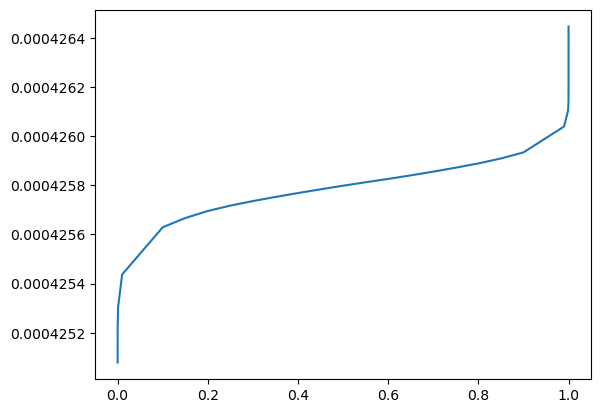

In [17]:
plt.plot(x, y)
print(min(y), max(y))

In [18]:
# find fence: 3239365
from sanity_check_v2 import fence
print(fence((y, x)))

(0.00042474844444227353, 0.00042700947512700475)


In [43]:
# consolidate it all to design a comprehensive test
# 1. Look into the TUI and pick a few results
# [(model, date, reference_date, idstring, (fence_low, fence_high), no_left_violations,
# no_of_right_violations]
# 2. Then find the corresponding raw data and t-digest for those and verify that the results
# are correct